<div align="center">
    
## <font color = blue>**Diabetic Retinopathy Exploratory Data Analysis and Preprocessing**</font>
<div>

**Dataset Overview:** The dataset contains contains a large number of detailed retinal photographs acquired under different imaging settings. For every participant, two images are available, one for the left eye and one for the right, with filenames that combine the subject’s identifier and the side of the eye. Each photograph has been examined by a clinician and assigned a diabetic retinopathy grade on a five-level severity scale. The grading scheme ranges from 0, indicating the absence of retinopathy, to 1 for mild cases, 2 for moderate cases, 3 for severe cases, and 4 for proliferative diabetic retinopathy.

The primary objective of this notebook is to conduct an Exploratory Data Analysis (EDA) and develop a robust preprocessing pipeline for detecting Diabetic Retinopathy. In medical imaging, raw data is rarely suitable for direct model input, as retinal fundus images often exhibit inconsistent lighting, varying resolutions, and clinical artifacts. In addition, the biological characteristics of the disease and severe class imbalance must be carefully considered to ensure reliable model development and evaluation.

This analysis is structured in two main phases. First, the EDA goes beyond basic descriptive statistics to examine key properties of the dataset, including class distribution to identify majority class bias, inter-eye symmetry to guide data splitting and prevent leakage, brightness consistency to ensure models learn pathology rather than imaging noise, and geometric variability to inform resizing strategies. Second, a multi-stage preprocessing pipeline is implemented based on these insights, including automated cropping to remove non-informative borders, radius-based scaling to standardize retinal size, Ben Graham’s contrast enhancement to highlight clinically relevant features such as microaneurysms and hemorrhages, circular masking to eliminate edge artifacts, and patient-level data splitting to ensure realistic model generalization. 


### <font color = #41EA46> **1: Import Libraries**</font>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import cv2
from PIL import Image
from tqdm import tqdm

from multiprocessing import Pool
import importlib
import worker_script

from sklearn.model_selection import GroupShuffleSplit

import warnings
warnings.filterwarnings("ignore")

### <font color = #41EA46> **2: Load dataset**<font>

In [2]:
# Load labels
labels_df = pd.read_csv("trainLabels.csv")

print("\n===== BASIC INFO =====")
image_count = sum(
    1 for file in os.listdir("train")
    if file.lower().endswith(".jpeg"))

print("Total Images:", image_count)
print("Labels Dataset Shape:", labels_df.shape)    


===== BASIC INFO =====
Total Images: 35126
Labels Dataset Shape: (35126, 2)


### <font color = #41EA46> **3: Exploratory Data Analysis (EDA)**<font>

#### <font color = #4854E8> **3.1: Class Distribution of Diabetic Retinopathy Levels** </font>

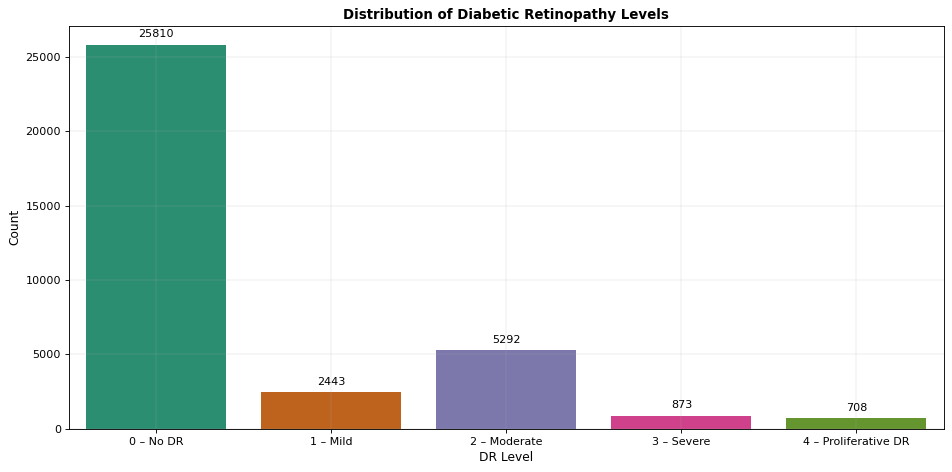

In [3]:
def class_imbalance_plot(labels_df):
    
    plt.figure(figsize=(12, 6), dpi=80)
    ax = sns.countplot(x='level', data=labels_df, palette="Dark2", legend=False)
    
    # Add count value above each bar
    for p in ax.patches:
        height = int(p.get_height())
        ax.annotate(f'{height}', xy=(p.get_x() + p.get_width() / 2, height), xytext=(0, 5), textcoords="offset points", ha='center', va='bottom',
                    fontsize=10, color='black')
        
    ax.set_xticks(range(5))
    ax.set_xticklabels(['0 – No DR','1 – Mild','2 – Moderate','3 – Severe','4 – Proliferative DR'])
    plt.xticks(fontsize=10, color='black')    
    plt.yticks(fontsize=10, color='black')
    plt.title('Distribution of Diabetic Retinopathy Levels', fontweight='bold', fontsize=12, color='black')
    plt.xlabel('DR Level', fontsize=11, color='black')
    plt.ylabel('Count', fontsize=11, color='black')
    plt.grid(True, linestyle='-', linewidth=0.3, alpha=0.6)
    plt.tight_layout()
    plt.show()

class_imbalance_plot(labels_df);

> Interpretation:
>
> **The dataset used in this study is highly imbalanced. This means that a large majority of the retinal images are labeled as having no signs of diabetic retinopathy (DR), while only a much smaller portion of the images represent mild, moderate, severe, or proliferative stages of the disease.**

---

#### <font color = #4854E8> **3.2: Symmetry Analysis (Left vs. Right Eye)** </font>

Diabetic Retinopathy (DR) is a condition that often affects both eyes. In many cases, if one eye shows signs of the disease, the other eye is also likely to be affected. Because of this, it is useful to examine how similar the disease severity is between a patient’s left and right eyes.

In [4]:
# Create a Patient ID column
labels_df['patient_id'] = labels_df['image'].str.split('_').str[0]
num_patients = labels_df['patient_id'].nunique()

print(f"Total Images: {len(labels_df)}")
print(f"Unique Patients: {num_patients}")

Total Images: 35126
Unique Patients: 17563


This confirms that the dataset is structured in pairs, where every patient has one image per eye.

In [5]:
# Extract PatientID and Eye from filename
labels_df['patient_id'] = labels_df['image'].apply(lambda x: x.split('_')[0])
labels_df['eye'] = labels_df['image'].apply(lambda x: x.split('_')[1].split('.')[0]) 

# Pivot to have one row per patient
eye_df = labels_df.pivot(index='patient_id', columns='eye', values='level').reset_index()

eye_df['match'] = eye_df['left'] == eye_df['right']
symmetry_ratio = eye_df['match'].mean()
print(f"Percentage of patients with identical grades in both eyes: {symmetry_ratio*100:.2f}%")

Percentage of patients with identical grades in both eyes: 87.25%


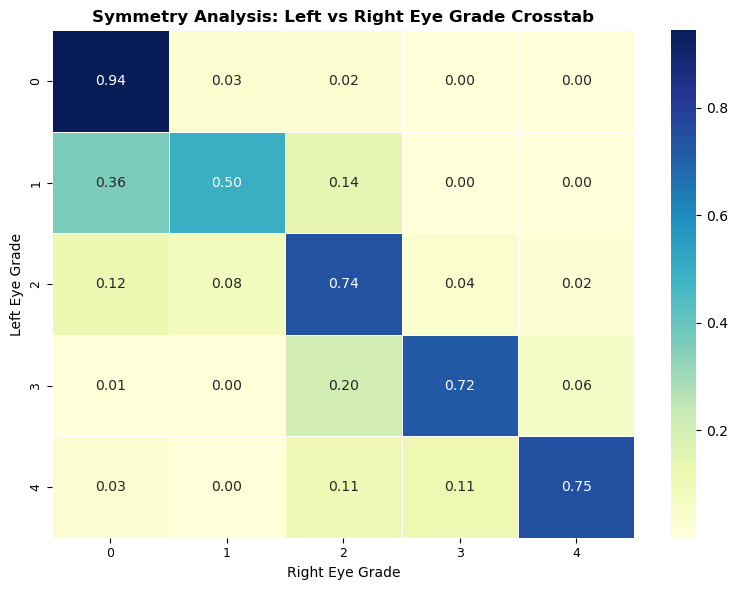

In [6]:
def symmetry_correlation_heatmap(eye_df):

    plt.figure(figsize=(8, 6))
    correlation_matrix = pd.crosstab(eye_df['left'], eye_df['right'], normalize='index')
    heatmap = sns.heatmap(correlation_matrix, cmap='YlGnBu', annot=True, fmt=".2f",  linewidths=0.5 )
    for text in heatmap.texts:
        text.set_fontsize(10)
        
    plt.title('Symmetry Analysis: Left vs Right Eye Grade Crosstab', fontsize=12, fontweight='bold', color='black')
    plt.xlabel('Right Eye Grade', fontsize=10)
    plt.ylabel('Left Eye Grade', fontsize=10)
    plt.xticks(fontsize=9, color='black')
    plt.yticks(fontsize=9, color='black')
    plt.gca().set_facecolor('#F5F5F5')
    plt.gca().spines['bottom'].set_color('black')
    plt.gca().spines['left'].set_color('black')
    plt.tight_layout()
    plt.show()

symmetry_correlation_heatmap(eye_df);

> Interpretation:
>
> **The analysis shows that 87.25% of patients have identical diabetic retinopathy grades in both eyes.**
>
> **For patients with no disease (Grade 0), the symmetry is nearly perfect at 0.94 (94%). If one eye is healthy, there is a very high probability the other is too.**
>
> **It also highlights that Grade 1 is the most 'unstable' phase, where the disease is most likely to be asymmetrical, where many patients with Grade 1 in their left eye are actually Grade 0 in their right eye (0.36).**
> 
> **It clearly indicates that diabetic retinopathy is highly symmetrical, meaning the severity level in one eye is very likely to be the same in the other eye. In other words, there is a strong relationship between the two eyes of the same patient.**
>

---

#### <font color = #4854E8> **3.3: Brightness Distribution by DR Level** </font>

This analysis examines how the overall brightness of retinal images varies across different levels of diabetic retinopathy (DR) to determine whether images from certain DR severity levels tend to be brighter or darker on average.

Starting parallel processing on 35126 images with 6 workers.


100%|████████████████████████████████████████████████████████████████████████████| 35126/35126 [49:21<00:00, 11.86it/s]


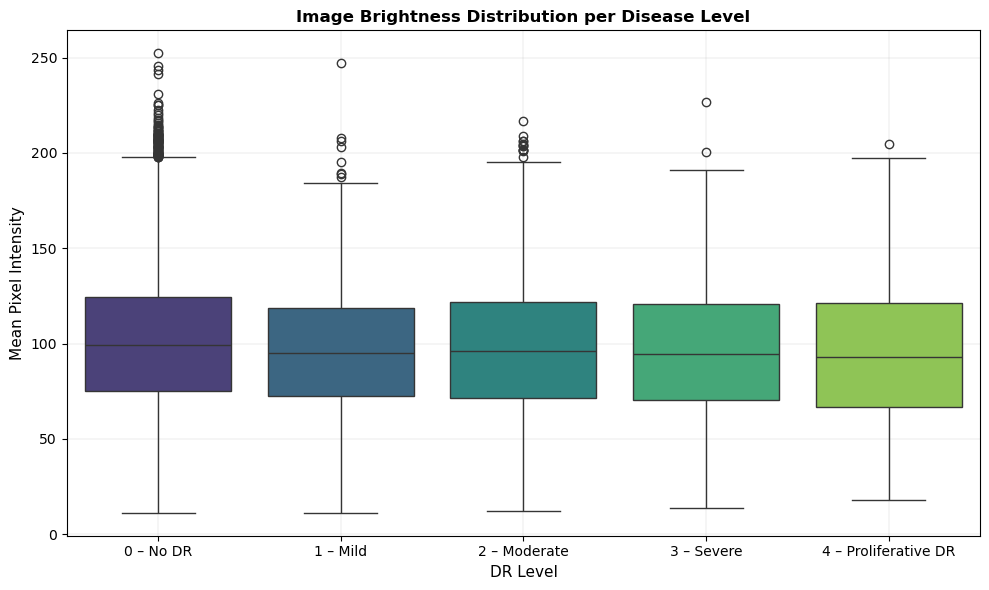

In [7]:
if __name__ == '__main__':
    # Configuration
    target_path = r"D:\train\train"
    num_processors= 6
    
    tasks = [(idx, row, target_path) for idx, row in labels_df.iterrows()]

    print(f"Starting parallel processing on {len(tasks)} images with {num_processors} workers.")
        
    # Using 'with' ensures the pool is closed properly even if it errors
    with Pool(processes=num_processors) as pool:
        results = list(tqdm(pool.imap(worker_script.process_single_image, tasks, chunksize=100), total=len(tasks)))
        # Filter out None results from missing or corrupt files
        
    brightness_data = [res for res in results if res is not None]
    brightness_df = pd.DataFrame(brightness_data)

    if not brightness_df.empty:
        plt.figure(figsize=(10, 6))
        ax = sns.boxplot(x='level', y='mean_intensity', data=brightness_df, palette='viridis')
        ax.set_xticks(range(5))
        ax.set_xticklabels(['0 – No DR', '1 – Mild','2 – Moderate','3 – Severe','4 – Proliferative DR'])
        plt.xticks(fontsize=10, color='black')    
        plt.yticks(fontsize=10, color='black')
        plt.title('Image Brightness Distribution per Disease Level', fontweight='bold', fontsize=12, color='black')
        plt.xlabel('DR Level', fontsize=11, color='black')
        plt.ylabel('Mean Pixel Intensity', fontsize=11, color='black')
        plt.grid(True, linestyle='-', linewidth=0.3, alpha=0.6)
        plt.tight_layout()
        plt.show()

> Interpretation:
>
> **The boxplot shows long “whiskers” and several extreme outliers. Some images have an average brightness value close to 250, which means they are almost completely white. On the other hand, some images have brightness values near 10, meaning they are extremely dark.**
>
> **Despite this large variation, the overall brightness distribution appears similar across all diabetic retinopathy (DR) severity levels. The boxplots for each grade are positioned at roughly the same height, suggesting that brightness is not strongly associated with a specific DR level.**
>

---

#### <font color = #4854E8> **3.4: Image Resolution & Shape Analysis** </font>

This analysis examines the size and shape characteristics of the retinal images in the dataset, specifically their resolution (image dimensions) and aspect ratio (relationship between width and height).

Extracting dimensions using Header-Only reading...


100%|███████████████████████████████████████████████████████████████████████████| 35126/35126 [04:34<00:00, 127.82it/s]


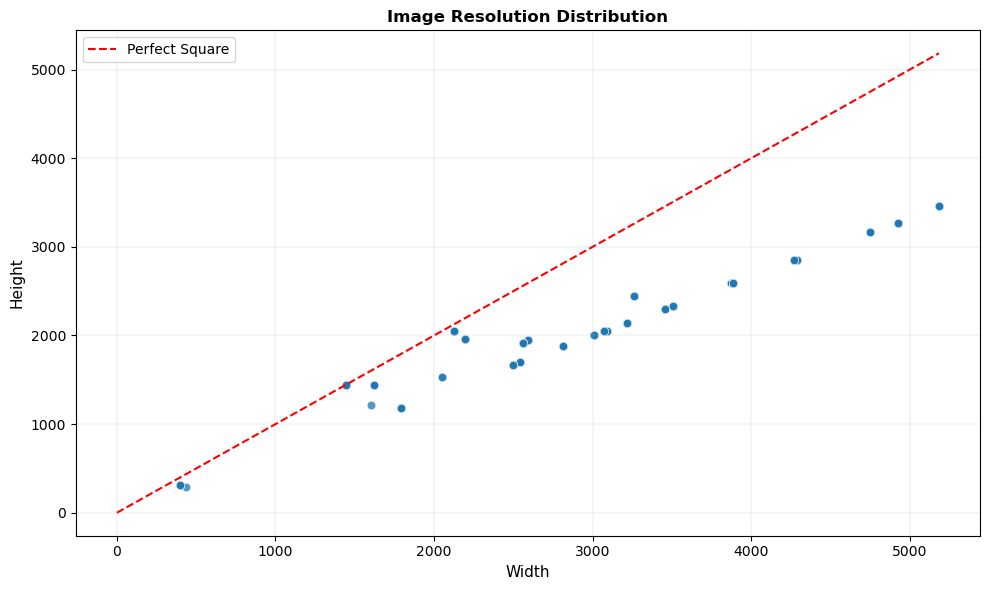

Average Resolution: 3637x2473
Average Aspect Ratio: 1.46


In [8]:
if __name__ == '__main__':
    
    target_path = r"D:\train\train"
    tasks = [(idx, row, target_path) for idx, row in labels_df.iterrows()]
    
    print("Extracting dimensions using Header-Only reading...")
    # Create a multiprocessing pool with 6 worker processes
    with Pool(processes=6) as pool:
        # Use imap for memory-efficient iteration over results
        # chunksize=200 improves performance since header reading is lightweigh
        results = list(tqdm(pool.imap(worker_script.get_image_dims, tasks, chunksize=200), total=len(tasks)))

    dims_df = pd.DataFrame([res for res in results if res is not None])

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=dims_df, x='width', y='height', alpha=0.5)
    
    # Determine max axis value for plotting reference line
    max_val = max(dims_df['width'].max(), dims_df['height'].max())
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Square')

    plt.xticks(fontsize=10, color='black')    
    plt.yticks(fontsize=10, color='black')
    plt.title('Image Resolution Distribution', fontweight='bold', fontsize=12, color='black')
    plt.xlabel('Width', fontsize=11, color='black')
    plt.ylabel('Height', fontsize=11, color='black')
    plt.grid(True, linestyle='-', linewidth=0.3, alpha=0.6)
    plt.legend(frameon=True, fontsize=10)
    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"Average Resolution: {dims_df['width'].mean():.0f}x{dims_df['height'].mean():.0f}")
    print(f"Average Aspect Ratio: {dims_df['aspect_ratio'].mean():.2f}")

> Interpretation:
>
> **Almost every point falls below the red "Perfect Square" line, showing that the images are predominantly wider than they are tall (landscape orientation).**
>
> **Image resolutions are extremely inconsistent. Some images are very small, around 500 pixels, while others are extremely large, exceeding 5000 pixels.**
>
> **The average aspect ratio of the dataset is 1.46, confirming that most images are rectangular rather than square. Directly resizing these images to a fixed square shape would distort the circular structures of the eye, potentially harming model performance.**

---

### <font color = #41EA46> **4: Data Preprocessing**<font>

#### <font color = #4854E8> **4.1: Image Preprocessing Pipeline** </font>

Before a machine learning model can effectively detect diabetic retinopathy, the raw retinal images must be carefully prepared. 
Here, the preprocessing acts like a refining lens for the retina. Raw images vary in lighting, resolution, aspect ratio, and background, and these inconsistencies can distract the model from focusing on actual medical features.

To address the inconsistencies uncovered during Exploratory Data Analysis (EDA), a multi-stage preprocessing pipeline was developed.

- **Automated Cropping and Noise Removal:** Many images contained large black borders around the retina, along with occasional artifacts or “light leaks” at the edges.
>
> An Automated Crop function was implemented to detect the bounding box of pixels above a brightness threshold and remove non-informative black margins. This ensures the model focuses entirely on retinal tissue, rather than empty or noisy areas.

- **Standardized Scaling:** Some photos are taken from far away, and some are very close up. This creates a problem for the model: a lesion that looks large in a close-up could appear tiny in a far-away image, even if it’s the same severity.
>
> The retina’s radius was calculated for each image using the middle row of pixels to measure the retina’s actual size, then resizing every image so the eyeball occupies a constant radius of 192 pixels, ensuring consistency across images.

>
- **Square Padding:** Images varied widely in resolution and aspect ratio due to different camera models and clinic settings. Some were wide rectangles, others tall, making direct resizing risky.
>
> To preserve anatomical proportions, images were placed on a square canvas with a neutral gray background (value 128). This avoids stretching the retina and maintains consistent input dimensions for the model. 


- **Local Contrast Enhancement (Ben-Graham Method):** Lighting in retinal photos was uneven, some images were hazy, orange-tinted, or bright in the center and dark at the edges. These conditions can obscure small but important features such as microaneurysms and hemorrhages.
>
> A Gaussian blur subtraction technique was applied by removing the local average brightness, enhancing contrast, and making the blood vessels and lesions (the actual signs of diabetic retinopathy) stand out in high contrast. This makes the critical markers of diabetic retinopathy much easier for the model to detect.

- **Circular Masking:** After Ben-Graham enhancement, edges often showed artificial glows or artifacts not present in the actual eye.
>
> A circular mask was applied, graying out everything outside the retina. This removes misleading edge artifacts and ensures the model analyzes only the relevant retinal area, reducing the chance of false positives.

_A Worker Script was used to run multiple images in parallel across all CPU cores to efficiently process over 35,000 high-resolution images, reducing processing time and handling corrupted images without stopping the pipeline. Each preprocessing stage was first developed and verified in separate modular notebook, providing a clear visual record of transformations and ensuring transparency, accuracy, and reproducibility._

In [9]:
if __name__ == '__main__':
    # Configuration
    input_dir = r"D:\train\train"
    output_dir = r"D:\train_preprocessed_384" 

    # Scaling constant used to resize images
    scale_constant = 192
    
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Prepare tasks (passing input and output paths)
    tasks = [(idx, row, input_dir, output_dir, scale_constant) 
             for idx, row in labels_df.iterrows()]

    print(f"Starting Image Preprocessing on {len(tasks)} images...")
    print(f"Output folder: {output_dir}")

    # Use multiprocessing pool with 6 workers
    # Balanced choice to avoid CPU overload + disk I/O bottleneck
    with Pool(processes=6) as pool:
        results = list(tqdm(pool.imap_unordered(worker_script.image_preprocess, tasks, chunksize=10), 
                            total=len(tasks)))
    # Count how many images were successfully processed 
    success_count = sum(results)
    print(f"Processing Complete! Successfully saved {success_count} images.")

Starting Image Preprocessing on 35126 images...
Output folder: D:\train_preprocessed_384


100%|████████████████████████████████████████████████████████████████████████████| 35126/35126 [29:44<00:00, 19.68it/s]

Processing Complete! Successfully saved 35126 images.


#### <font color = #4854E8> **4.2: Symmetry-Aware Data Splitting** </font>

In the above EDA, an 87.25% correlation between a patient’s left and right eyes was discovered. This means the disease is highly symmetrical. To prevent the model from seeing nearly identical images across training and test, a patient-level (group) split was utilized, keeping both eyes of each patient together in the same set and avoiding data leakage.

In [10]:
# Define the Splitter (80% Train, 20% Test)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)

# Execute the split based on patient_id
train_idx, test_idx = next(gss.split(labels_df, groups=labels_df['patient_id']))

# Assign labels
labels_df.loc[train_idx, 'split'] = 'train'
labels_df.loc[test_idx, 'split'] = 'test'

# Save the dataset to a csv
labels_df.to_csv(r"D:\trainLabels_preproccessed.csv", index=False)

print(f"Total Patients: {labels_df['patient_id'].nunique()}")
print(f"Training: {len(train_idx)} images ({labels_df.iloc[train_idx]['patient_id'].nunique()} patients)")
print(f"Testing:  {len(test_idx)} images ({labels_df.iloc[test_idx]['patient_id'].nunique()} patients)")

Total Patients: 17563
Training: 28100 images (14050 patients)
Testing:  7026 images (3513 patients)


In [11]:
labels_df.head(5)

,image,level,patient_id,eye,split
0,10_left,0,10,left,train
1,10_right,0,10,right,train
2,13_left,0,13,left,test
3,13_right,0,13,right,test
4,15_left,1,15,left,train


4.3 Addressing Class Imbalance

### <font color = #41EA46> **5: Data Augmentation and Normalization**<font>

- To improve model generalization and address class imbalance, a targeted data augmentation strategy was implemented using a custom PyTorch dataset pipeline. Augmentation was applied dynamically during training, meaning transformations were performed “on-the-fly” as images were loaded. This allowed the model to see different variations of the same image across epochs without increasing the dataset size.

- Following augmentation, images were converted into tensors and normalized using the ImageNet mean and standard deviation. This standardization ensures compatibility with pre-trained weights and contributes to more stable training by maintaining consistent input distribution.

---